# Prévision de la Température et de l'Irradiation Solaire — Benguerir (2026–2055)

## Pipeline complet : Machine Learning + Deep Learning

**Données** : NASA POWER — T2M (°C) + ALLSKY (W/m²) — 2001 à 2025  
**Modèle ML** : XGBoost + GridSearchCV + Validation Curves (TimeSeriesSplit)  
**Modèle DL** : LSTM Bidirectionnel + Lag Features + Prévision Autorégressive  
**Split** : 80% Train / 20% Test (chronologique)  
**Prévision** : 30 ans (2026–2055) — autorégressive avec mise à jour dynamique des lags

**Variables prédites :**
- **T2M** : Température à 2 mètres (°C)
- **ALLSKY** : Irradiation solaire All-Sky Surface Shortwave Downward (W/m²)


## 1. Imports et Configuration


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices())


print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, validation_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

np.random.seed(42)
tf.random.set_seed(42)

# Vérification GPU
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✓ GPU détecté : {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠ Aucun GPU détecté — exécution CPU (plus lent pour LSTM)")

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")


✓ GPU détecté : /physical_device:GPU:0
TensorFlow : 2.10.0
NumPy      : 1.26.4
Pandas     : 2.3.3


## 2. Chargement des Données


In [3]:
df = pd.read_csv("data_horaire.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

print(f"Données : {len(df)} heures | {df.index[0]} → {df.index[-1]}")
print(f"T2M   — Min={df['T2M'].min():.1f}°C | Max={df['T2M'].max():.1f}°C | Moy={df['T2M'].mean():.1f}°C")
print(f"ALLSKY — Min={df['ALLSKY'].min():.1f} | Max={df['ALLSKY'].max():.1f} | Moy={df['ALLSKY'].mean():.1f} W/m²")
print(f"\nNaN : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")

# ── Traitement des NaN ALLSKY (nov-déc 2025) ─────────────────────
df["ALLSKY"] = df["ALLSKY"].interpolate(method="linear", limit=48)
remaining_nan = df["ALLSKY"].isna().sum()
print(f"Après interpolation (limit=48h) : {remaining_nan} NaN restants → remplissage par moyenne horaire mensuelle")

# Remplir les NaN restants par la moyenne horaire du même mois (années précédentes)
df["_month"] = df.index.month
df["_hour"] = df.index.hour
monthly_hourly_mean = df.groupby(["_month", "_hour"])["ALLSKY"].transform("mean")
df["ALLSKY"] = df["ALLSKY"].fillna(monthly_hourly_mean)
df = df.drop(columns=["_month", "_hour"])

print(f"NaN après remplissage complet : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")
df.head()


Données : 219144 heures | 2001-01-01 00:00:00 → 2025-12-31 23:00:00
T2M   — Min=-3.4°C | Max=47.5°C | Moy=19.9°C
ALLSKY — Min=0.0 | Max=1065.6 | Moy=234.0 W/m²

NaN : T2M=0, ALLSKY=762
Après interpolation (limit=48h) : 714 NaN restants → remplissage par moyenne horaire mensuelle
NaN après remplissage complet : T2M=0, ALLSKY=0


,ALLSKY,T2M
datetime,,
2001-01-01 00:00:00,0.0,10.04
2001-01-01 01:00:00,0.0,9.89
2001-01-01 02:00:00,0.0,9.91
2001-01-01 03:00:00,0.0,9.98
2001-01-01 04:00:00,0.0,9.85


## 3. Feature Engineering (issu de l'analyse statistique)

- **Encodage cyclique** : fréquences dominantes 24h, 168h, 365.25 jours (analyse spectrale)
- **Régimes thermiques** : seuils validés par Kruskal-Wallis + Mann-Whitney
- **Saisonnalité mensuelle** : validée par test non-paramétrique
- **Interactions croisées** : heure × mois, heure × saison
- **Lag features** : cycles dominants identifiés par l'analyse spectrale (1h à 72h)
- **Rolling features** : moyennes et écart-types glissants (24h, 72h)


In [4]:
def create_features(dataframe):
    """Features temporelles issues de l'analyse statistique."""
    d = dataframe.copy()
    idx = d.index

    # Features temporelles brutes
    d["hour"]         = idx.hour
    d["day_of_week"]  = idx.dayofweek
    d["month"]        = idx.month
    d["day_of_year"]  = idx.dayofyear
    d["week_of_year"] = idx.isocalendar().week.astype(int).values
    d["quarter"]      = idx.quarter

    # Encodage cyclique (fréquences dominantes de l'analyse spectrale)
    d["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    d["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    d["dow_sin"]  = np.sin(2 * np.pi * idx.dayofweek / 7)
    d["dow_cos"]  = np.cos(2 * np.pi * idx.dayofweek / 7)
    d["moy_sin"]  = np.sin(2 * np.pi * idx.month / 12)
    d["moy_cos"]  = np.cos(2 * np.pi * idx.month / 12)
    d["doy_sin"]  = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    d["doy_cos"]  = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    # Indicateurs solaires (basés sur l'heure)
    d["is_daytime"]   = ((idx.hour >= 6) & (idx.hour <= 19)).astype(int)
    d["solar_peak"]   = ((idx.hour >= 10) & (idx.hour <= 15)).astype(int)
    d["night"]        = ((idx.hour >= 21) | (idx.hour <= 4)).astype(int)

    # Saisons (Benguerir = hémisphère nord)
    d["is_summer"] = ((idx.month >= 6) & (idx.month <= 8)).astype(int)
    d["is_winter"] = ((idx.month == 12) | (idx.month <= 2)).astype(int)

    # Interactions croisées
    d["hour_x_month"]  = d["hour"] * d["month"]
    d["hour_x_summer"] = d["hour"] * d["is_summer"]

    return d


def create_features_with_lags(dataframe, target_col):
    """Features temporelles + lag features pour le LSTM dynamique."""
    d = create_features(dataframe)

    # Lag features — cycles dominants identifiés par l'analyse spectrale
    for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
        d[f"lag_{lag}h"] = d[target_col].shift(lag)

    # Moyennes glissantes
    d[f"rolling_24h_mean"] = d[target_col].rolling(24, min_periods=1).mean()
    d[f"rolling_72h_mean"] = d[target_col].rolling(72, min_periods=1).mean()

    # Écart-type glissant (volatilité)
    d[f"rolling_24h_std"] = d[target_col].rolling(24, min_periods=1).std().fillna(0)

    # Supprimer les NaN dus aux lags
    d = d.dropna()
    return d


def calc_metrics(y_true, y_pred):
    """Calcule R², RMSE et MAE."""
    return {
        "R²":   r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred)
    }

print("✓ Fonctions de feature engineering définies")


✓ Fonctions de feature engineering définies


---
# ════════════════════════════════════════════════════════════════
# PARTIE A — PRÉVISION DE LA TEMPÉRATURE (T2M)
# ════════════════════════════════════════════════════════════════


## 4. Feature Engineering — T2M


In [5]:
# Features de base pour XGBoost
df_feat_t = create_features(df[["T2M"]])
feature_cols_t = [c for c in df_feat_t.columns if c != "T2M"]
print(f"Features de base T2M : {len(feature_cols_t)}")

# Split Train/Test 80/20 chronologique
split_idx_t = int(len(df_feat_t) * 0.8)
train_t = df_feat_t.iloc[:split_idx_t]
test_t  = df_feat_t.iloc[split_idx_t:]

X_train_t, y_train_t = train_t[feature_cols_t].values, train_t["T2M"].values
X_test_t,  y_test_t  = test_t[feature_cols_t].values,  test_t["T2M"].values

print(f"Train : {len(X_train_t):,} ({train_t.index[0].date()} → {train_t.index[-1].date()})")
print(f"Test  : {len(X_test_t):,}  ({test_t.index[0].date()} → {test_t.index[-1].date()})")


Features de base T2M : 21
Train : 175,315 (2001-01-01 → 2020-12-31)
Test  : 43,829  (2020-12-31 → 2025-12-31)


## 5. XGBoost — GridSearchCV + Validation Curves (T2M)


In [6]:
print("GridSearchCV XGBoost T2M (TimeSeriesSplit, 3 folds)...")
tscv = TimeSeriesSplit(n_splits=3)

param_grid_t = {
    "n_estimators": [100,200,300, 400, 600, 500,700, 800,900],
    "max_depth": [1,2,3,4,5, 6,7, 8,9, 10,11],
    "learning_rate": [0.01, 0.05, 0.1,0.03,0.2,0.5,0.07],
}

grid_t = GridSearchCV(
    XGBRegressor(
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
    ),
    param_grid_t, cv=tscv, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=0, return_train_score=True
)
grid_t.fit(X_train_t, y_train_t)

bp_t = grid_t.best_params_
print(f"\n  Best params  : {bp_t}")
print(f"  Best CV RMSE : {np.sqrt(-grid_t.best_score_):.4f} °C")


GridSearchCV XGBoost T2M (TimeSeriesSplit, 3 folds)...


KeyboardInterrupt: 

Validation Curve T2M (max_depth)...
Validation Curve T2M (n_estimators)...


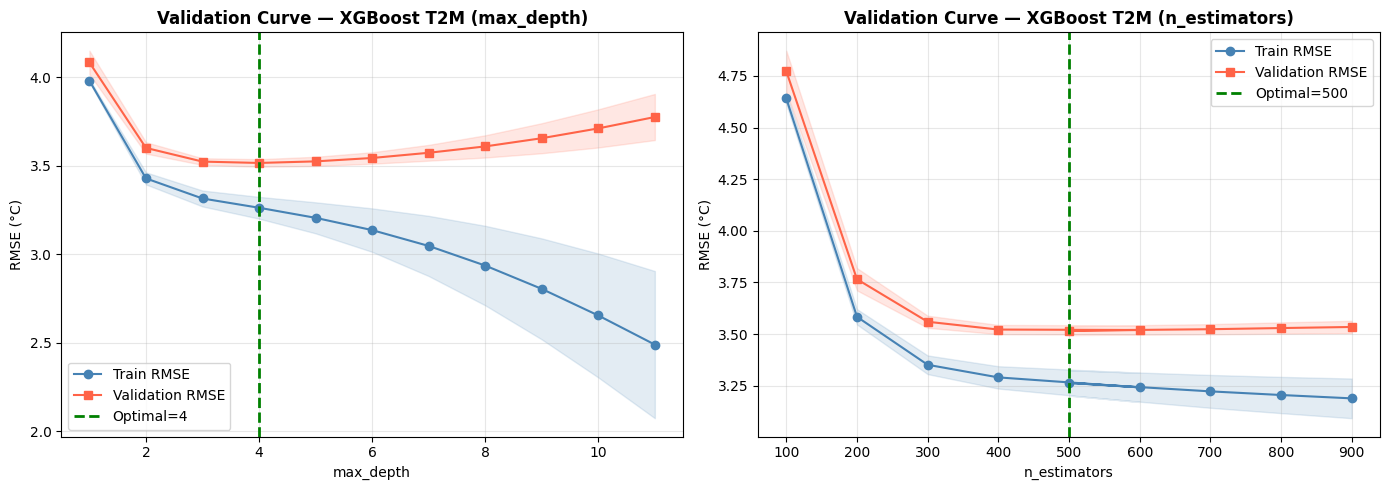

: 

: 

In [ ]:
# ── Validation Curve : max_depth ──────────────────────────────────
print("Validation Curve T2M (max_depth)...")
depth_range = np.arange(1, 12)

xgb_vc_t = XGBRegressor(
    n_estimators=bp_t["n_estimators"], learning_rate=bp_t["learning_rate"],
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)

ts_d_t, vs_d_t = validation_curve(
    xgb_vc_t, X_train_t, y_train_t, param_name="max_depth",
    param_range=depth_range, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
)
tr_d_t, vr_d_t = np.sqrt(-ts_d_t), np.sqrt(-vs_d_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_range, tr_d_t.mean(1), "o-", color="steelblue", label="Train RMSE")
axes[0].fill_between(depth_range, tr_d_t.mean(1)-tr_d_t.std(1), tr_d_t.mean(1)+tr_d_t.std(1),
                alpha=0.15, color="steelblue")
axes[0].plot(depth_range, vr_d_t.mean(1), "s-", color="tomato", label="Validation RMSE")
axes[0].fill_between(depth_range, vr_d_t.mean(1)-vr_d_t.std(1), vr_d_t.mean(1)+vr_d_t.std(1),
                alpha=0.15, color="tomato")
axes[0].axvline(bp_t["max_depth"], color="green", ls="--", lw=2, label=f"Optimal={bp_t['max_depth']}")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("RMSE (°C)")
axes[0].set_title("Validation Curve — XGBoost T2M (max_depth)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Validation Curve : n_estimators ──────────────────────────────
print("Validation Curve T2M (n_estimators)...")
nest_range = np.array([100,200,300, 400, 600, 500,700, 800,900])

xgb_vc2_t = XGBRegressor(
    max_depth=bp_t["max_depth"], learning_rate=bp_t["learning_rate"],
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)

ts_n_t, vs_n_t = validation_curve(
    xgb_vc2_t, X_train_t, y_train_t, param_name="n_estimators",
    param_range=nest_range, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
)
tr_n_t, vr_n_t = np.sqrt(-ts_n_t), np.sqrt(-vs_n_t)

axes[1].plot(nest_range, tr_n_t.mean(1), "o-", color="steelblue", label="Train RMSE")
axes[1].fill_between(nest_range, tr_n_t.mean(1)-tr_n_t.std(1), tr_n_t.mean(1)+tr_n_t.std(1),
                alpha=0.15, color="steelblue")
axes[1].plot(nest_range, vr_n_t.mean(1), "s-", color="tomato", label="Validation RMSE")
axes[1].fill_between(nest_range, vr_n_t.mean(1)-vr_n_t.std(1), vr_n_t.mean(1)+vr_n_t.std(1),
                alpha=0.15, color="tomato")
axes[1].axvline(bp_t["n_estimators"], color="green", ls="--", lw=2, label=f"Optimal={bp_t['n_estimators']}")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("RMSE (°C)")
axes[1].set_title("Validation Curve — XGBoost T2M (n_estimators)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Métriques & Visualisation XGBoost — T2M


╔══════════════════════════════════════════════════════════════╗
║  MÉTRIQUES XGBOOST T2M — TRAIN + TEST                       ║
╚══════════════════════════════════════════════════════════════╝
  TRAIN →  R²=0.8455  |  RMSE=3.3676 °C  |  MAE=2.6507 °C
  TEST  →  R²=0.8078  |  RMSE=3.6775 °C  |  MAE=2.8737 °C


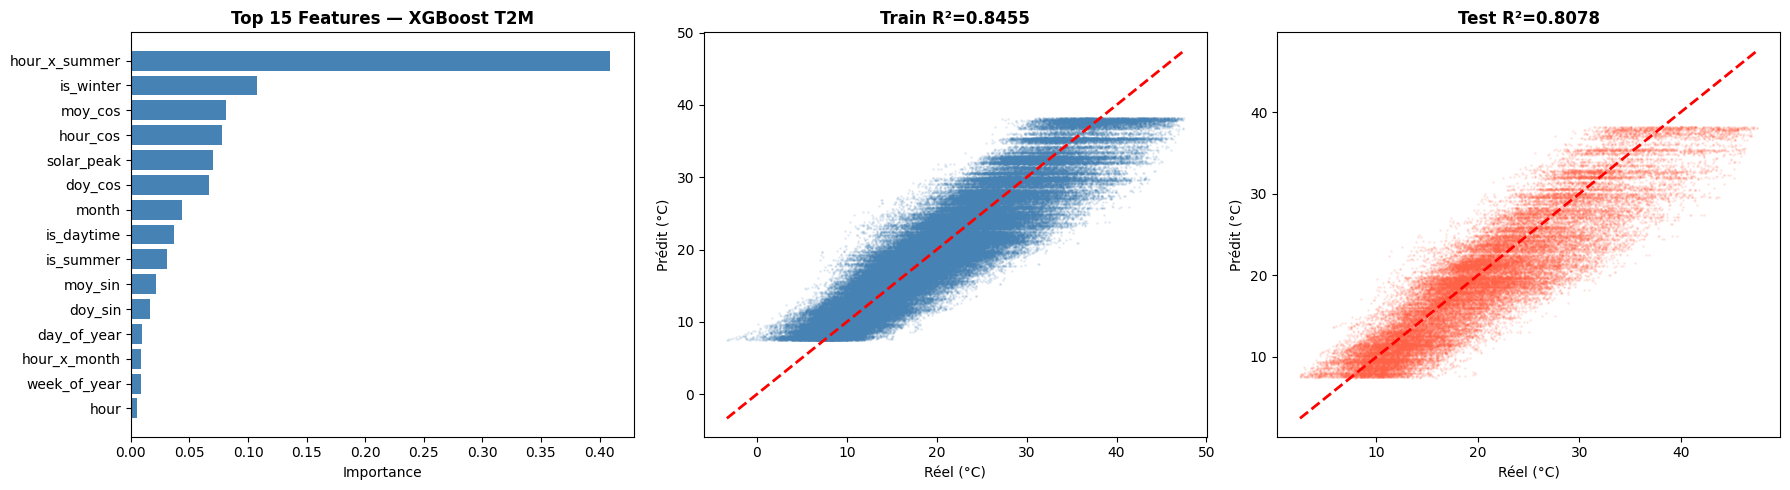

In [8]:
xgb_best_t = grid_t.best_estimator_
y_tr_xgb_t = xgb_best_t.predict(X_train_t)
y_te_xgb_t = xgb_best_t.predict(X_test_t)

xgb_train_mt = calc_metrics(y_train_t, y_tr_xgb_t)
xgb_test_mt  = calc_metrics(y_test_t, y_te_xgb_t)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES XGBOOST T2M — TRAIN + TEST{' '*23}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={xgb_train_mt['R²']:.4f}  |  RMSE={xgb_train_mt['RMSE']:.4f} °C  |  MAE={xgb_train_mt['MAE']:.4f} °C")
print(f"  TEST  →  R²={xgb_test_mt['R²']:.4f}  |  RMSE={xgb_test_mt['RMSE']:.4f} °C  |  MAE={xgb_test_mt['MAE']:.4f} °C")

# Feature Importance
imp_t = xgb_best_t.feature_importances_
si_t = np.argsort(imp_t)[::-1][:15]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(range(len(si_t)), imp_t[si_t][::-1], color="steelblue")
axes[0].set_yticks(range(len(si_t)))
axes[0].set_yticklabels([feature_cols_t[i] for i in si_t][::-1])
axes[0].set_xlabel("Importance")
axes[0].set_title("Top 15 Features — XGBoost T2M", fontweight="bold")

# Train vs Test
axes[1].scatter(y_train_t, y_tr_xgb_t, s=1, alpha=0.1, color="steelblue")
axes[1].plot([y_train_t.min(), y_train_t.max()], [y_train_t.min(), y_train_t.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (°C)"); axes[1].set_ylabel("Prédit (°C)")
axes[1].set_title(f"Train R²={xgb_train_mt['R²']:.4f}", fontweight="bold")

axes[2].scatter(y_test_t, y_te_xgb_t, s=1, alpha=0.1, color="tomato")
axes[2].plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], "r--", lw=2)
axes[2].set_xlabel("Réel (°C)"); axes[2].set_ylabel("Prédit (°C)")
axes[2].set_title(f"Test R²={xgb_test_mt['R²']:.4f}", fontweight="bold")

plt.tight_layout(); plt.show()


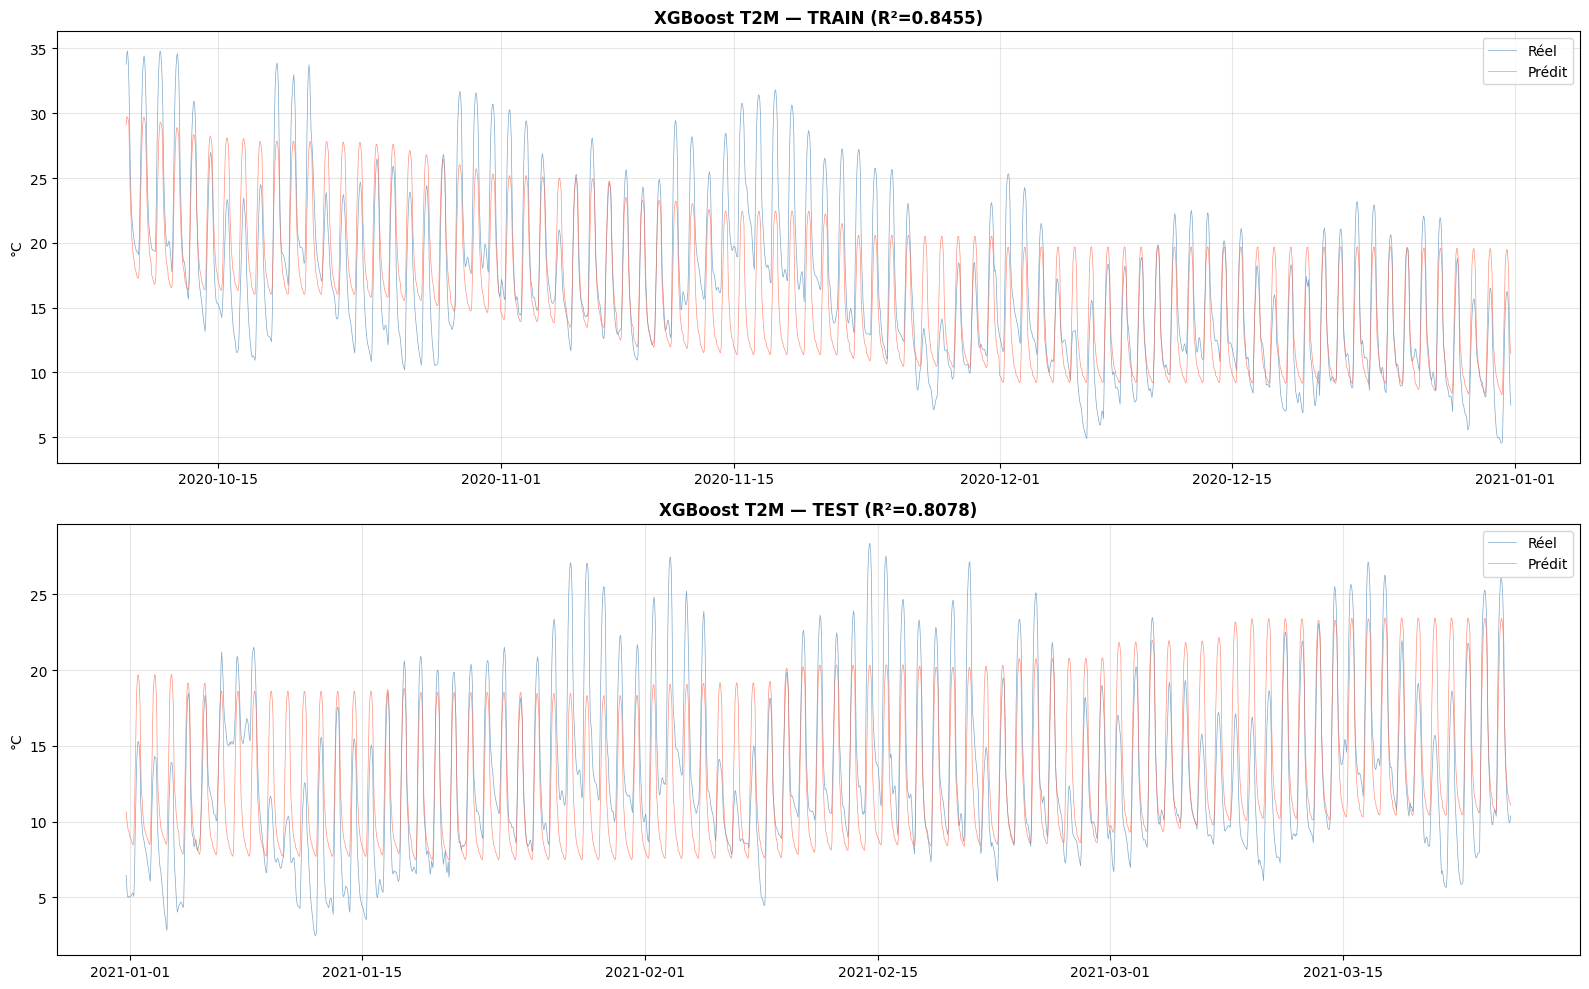

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_t.index[-2000:], y_train_t[-2000:], lw=0.5, color="steelblue", alpha=0.7, label="Réel")
axes[0].plot(train_t.index[-2000:], y_tr_xgb_t[-2000:], lw=0.5, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"XGBoost T2M — TRAIN (R²={xgb_train_mt['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("°C"); axes[0].grid(True, alpha=0.3)

axes[1].plot(test_t.index[:2000], y_test_t[:2000], lw=0.5, color="steelblue", alpha=0.7, label="Réel")
axes[1].plot(test_t.index[:2000], y_te_xgb_t[:2000], lw=0.5, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"XGBoost T2M — TEST (R²={xgb_test_mt['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("°C"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## 7. LSTM Bidirectionnel — T2M

### 7.1 Préparation des données LSTM (avec lags dynamiques)


In [6]:
LOOKBACK = 72  # 3 jours (cycles dominants 24h de l'analyse spectrale)

# Dataset enrichi avec lags pour T2M
df_feat_lag_t = create_features_with_lags(df[["T2M"]], "T2M")
feature_cols_lag_t = [c for c in df_feat_lag_t.columns if c != "T2M"]

print(f"Features avec lags T2M : {len(feature_cols_lag_t)}")
print(f"Lag/Rolling features : {[c for c in feature_cols_lag_t if 'lag' in c or 'rolling' in c]}")

# Scaling
X_all_lag_t = df_feat_lag_t[feature_cols_lag_t].values
y_all_lag_t = df_feat_lag_t["T2M"].values

scaler_X_t = MinMaxScaler()
scaler_y_t = MinMaxScaler()
X_sc_t = scaler_X_t.fit_transform(X_all_lag_t)
y_sc_t = scaler_y_t.fit_transform(y_all_lag_t.reshape(-1, 1)).flatten()

# Création des séquences
def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq_t, y_seq_t = make_sequences(X_sc_t, y_sc_t, LOOKBACK)

# Split temporel
sp_t = int(len(X_seq_t) * 0.8)
X_tr_lstm_t, X_te_lstm_t = X_seq_t[:sp_t], X_seq_t[sp_t:]
y_tr_lstm_t, y_te_lstm_t = y_seq_t[:sp_t], y_seq_t[sp_t:]

print(f"\nLookback = {LOOKBACK}h")
print(f"Train : {X_tr_lstm_t.shape}  |  Test : {X_te_lstm_t.shape}")


Features avec lags T2M : 32
Lag/Rolling features : ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'rolling_24h_mean', 'rolling_72h_mean', 'rolling_24h_std']

Lookback = 72h
Train : (175200, 72, 32)  |  Test : (43800, 72, 32)


### 7.2 Architecture et Entraînement LSTM — T2M


In [7]:
model_lstm_t = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(LOOKBACK, len(feature_cols_lag_t))),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm_t.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss=Huber(delta=1.0),
    metrics=["mae"]
)

model_lstm_t.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 72, 256)          164864    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 72, 256)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 72, 128)          164352    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 72, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0

In [8]:
print("Entraînement LSTM T2M...")

history_t = model_lstm_t.fit(
    X_tr_lstm_t, y_tr_lstm_t,
    validation_data=(X_te_lstm_t, y_te_lstm_t),
    epochs=50, batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-9, verbose=1)
    ],
    verbose=2
)


Entraînement LSTM T2M...
Epoch 1/50
5475/5475 - 239s - loss: 6.4769e-04 - mae: 0.0261 - val_loss: 0.0012 - val_mae: 0.0392 - lr: 0.0010 - 239s/epoch - 44ms/step
Epoch 2/50
5475/5475 - 228s - loss: 2.7710e-04 - mae: 0.0180 - val_loss: 0.0012 - val_mae: 0.0375 - lr: 0.0010 - 228s/epoch - 42ms/step
Epoch 3/50
5475/5475 - 232s - loss: 2.1519e-04 - mae: 0.0158 - val_loss: 0.0012 - val_mae: 0.0378 - lr: 0.0010 - 232s/epoch - 42ms/step
Epoch 4/50

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5475/5475 - 211s - loss: 1.7885e-04 - mae: 0.0144 - val_loss: 0.0012 - val_mae: 0.0404 - lr: 0.0010 - 211s/epoch - 38ms/step
Epoch 5/50
5475/5475 - 218s - loss: 1.3423e-04 - mae: 0.0123 - val_loss: 0.0011 - val_mae: 0.0371 - lr: 5.0000e-04 - 218s/epoch - 40ms/step
Epoch 6/50
5475/5475 - 229s - loss: 1.2669e-04 - mae: 0.0119 - val_loss: 0.0014 - val_mae: 0.0428 - lr: 5.0000e-04 - 229s/epoch - 42ms/step
Epoch 7/50
5475/5475 - 228s - loss: 1.1959e-04 - mae: 0.0115 - val_loss: 0

### 7.3 Courbes d'apprentissage & Métriques LSTM — T2M


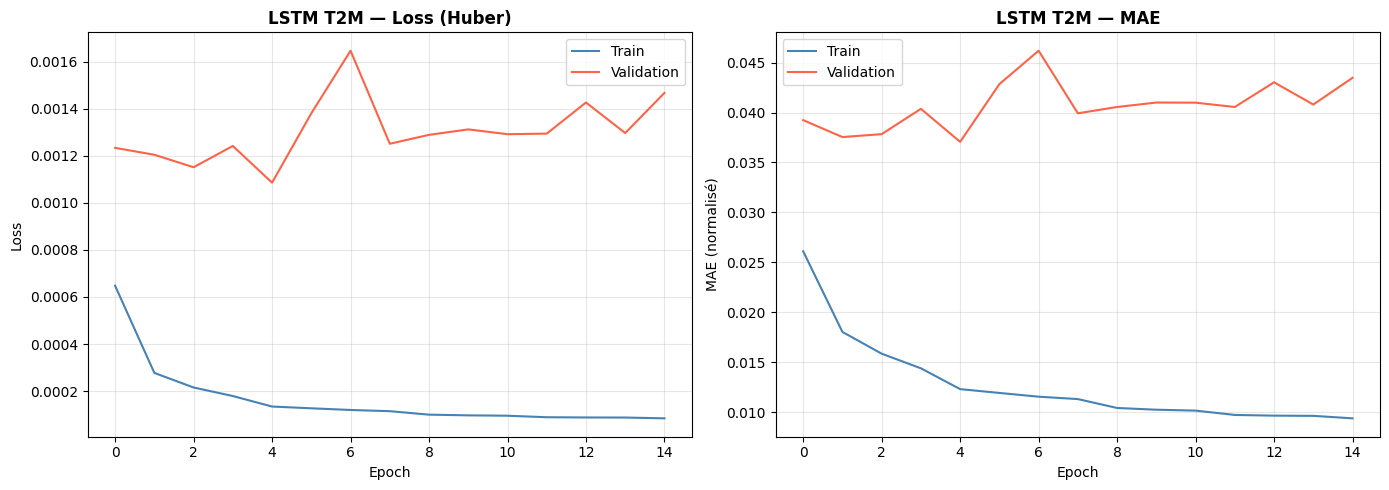

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_t.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_t.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM T2M — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_t.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_t.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM T2M — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (normalisé)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


ytr_lstm_t = scaler_y_t.inverse_transform(model_lstm_t.predict(X_tr_lstm_t, verbose=0).reshape(-1, 1)).flatten()
yte_lstm_t = scaler_y_t.inverse_transform(model_lstm_t.predict(X_te_lstm_t, verbose=0).reshape(-1, 1)).flatten()
ytr_real_t = scaler_y_t.inverse_transform(y_tr_lstm_t.reshape(-1, 1)).flatten()
yte_real_t = scaler_y_t.inverse_transform(y_te_lstm_t.reshape(-1, 1)).flatten()

lstm_train_mt = calc_metrics(ytr_real_t, ytr_lstm_t)
lstm_test_mt  = calc_metrics(yte_real_t, yte_lstm_t)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM T2M — TRAIN + TEST{' '*26}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_mt['R²']:.4f}  |  RMSE={lstm_train_mt['RMSE']:.4f} °C  |  MAE={lstm_train_mt['MAE']:.4f} °C")
print(f"  TEST  →  R²={lstm_test_mt['R²']:.4f}  |  RMSE={lstm_test_mt['RMSE']:.4f} °C  |  MAE={lstm_test_mt['MAE']:.4f} °C")

# Visualisation
split_idx_lag_t = int(len(df_feat_lag_t) * 0.8)
train_idx_lstm_t = df_feat_lag_t.index[LOOKBACK:LOOKBACK + len(ytr_real_t)]
test_idx_lstm_t  = df_feat_lag_t.index[split_idx_lag_t + LOOKBACK:][:len(yte_real_t)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_idx_lstm_t[-2000:], ytr_real_t[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_t[-2000:], ytr_lstm_t[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM T2M — TRAIN (R²={lstm_train_mt['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("°C"); axes[0].grid(True, alpha=0.3)

n_te = min(len(test_idx_lstm_t), len(yte_real_t))
axes[1].plot(test_idx_lstm_t[:n_te], yte_real_t[:n_te], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_t[:n_te], yte_lstm_t[:n_te], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM T2M — TEST (R²={lstm_test_mt['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("°C"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [12]:
def safe_predict(model, X, batch_size=64):
    preds = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        preds.append(model.predict(batch, verbose=0))
    return np.vstack(preds)

╔══════════════════════════════════════════════════════════════╗
║  MÉTRIQUES LSTM T2M — TRAIN + TEST                          ║
╚══════════════════════════════════════════════════════════════╝
  TRAIN →  R²=0.9327  |  RMSE=2.2230 °C  |  MAE=1.7418 °C
  TEST  →  R²=0.9201  |  RMSE=2.3701 °C  |  MAE=1.8852 °C


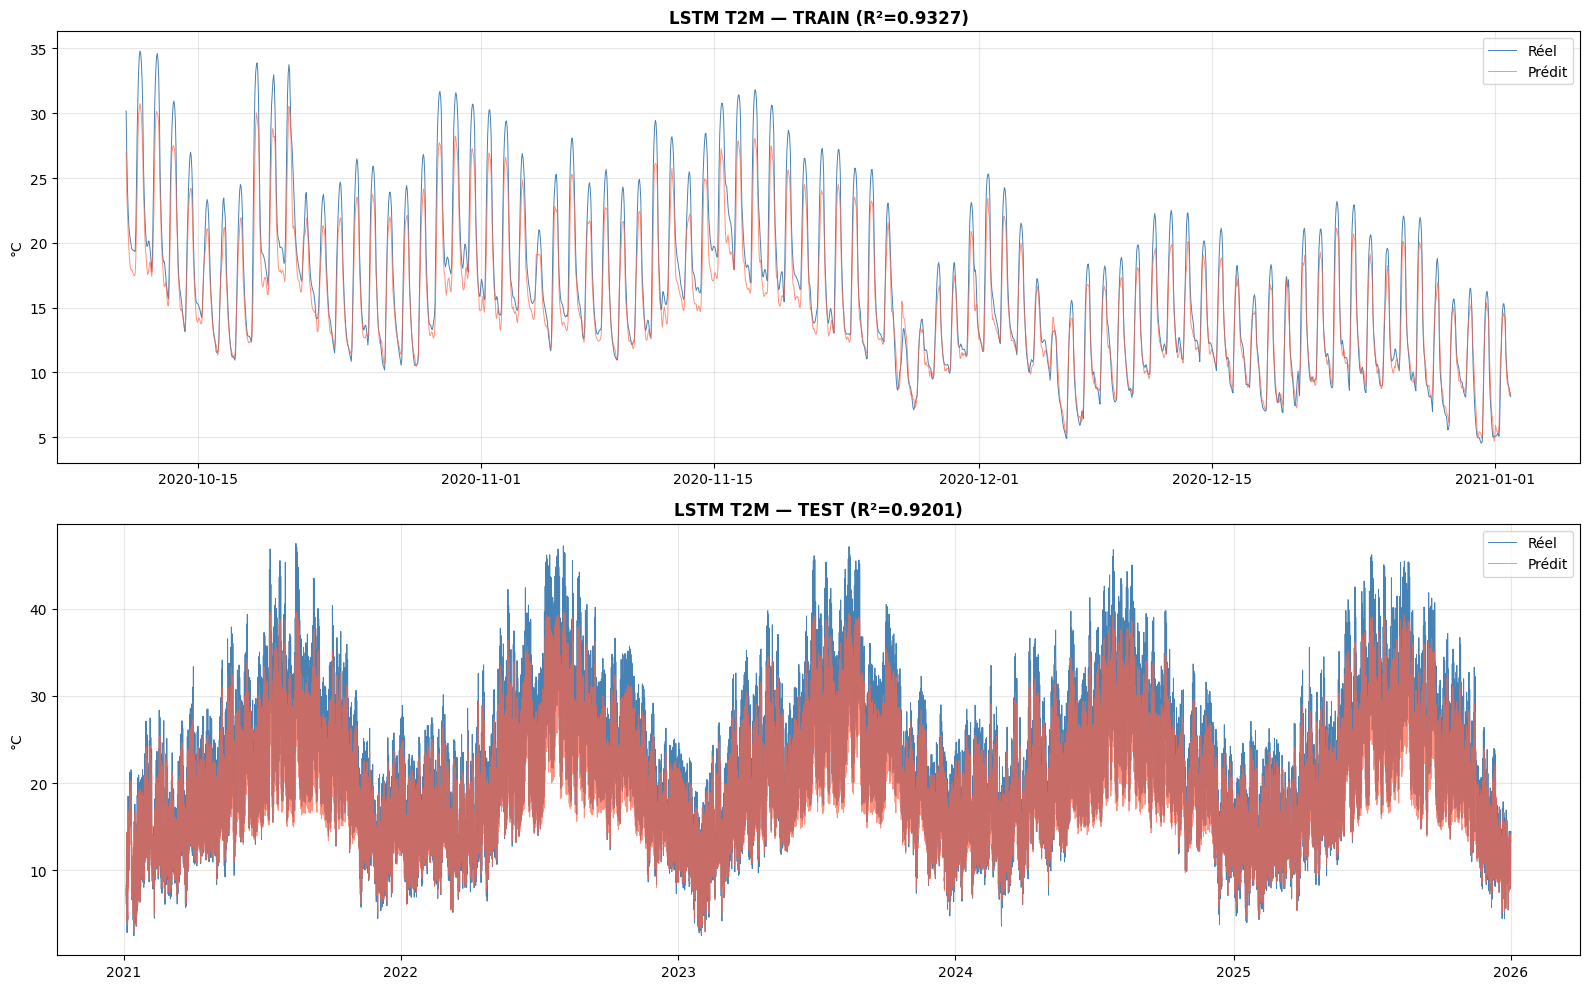

In [13]:
# Libérer la mémoire GPU après l'entraînement
import gc
gc.collect()
tf.keras.backend.clear_session()

# Prédiction par batchs (évite OOM GPU)
ytr_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_tr_lstm_t, batch_size=64).reshape(-1, 1)).flatten()
yte_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_te_lstm_t, batch_size=64).reshape(-1, 1)).flatten()
ytr_real_t = scaler_y_t.inverse_transform(y_tr_lstm_t.reshape(-1, 1)).flatten()
yte_real_t = scaler_y_t.inverse_transform(y_te_lstm_t.reshape(-1, 1)).flatten()

lstm_train_mt = calc_metrics(ytr_real_t, ytr_lstm_t)
lstm_test_mt  = calc_metrics(yte_real_t, yte_lstm_t)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM T2M — TRAIN + TEST{' '*26}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_mt['R²']:.4f}  |  RMSE={lstm_train_mt['RMSE']:.4f} °C  |  MAE={lstm_train_mt['MAE']:.4f} °C")
print(f"  TEST  →  R²={lstm_test_mt['R²']:.4f}  |  RMSE={lstm_test_mt['RMSE']:.4f} °C  |  MAE={lstm_test_mt['MAE']:.4f} °C")

# Visualisation
split_idx_lag_t = int(len(df_feat_lag_t) * 0.8)
train_idx_lstm_t = df_feat_lag_t.index[LOOKBACK:LOOKBACK + len(ytr_real_t)]
test_idx_lstm_t  = df_feat_lag_t.index[split_idx_lag_t + LOOKBACK:][:len(yte_real_t)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_idx_lstm_t[-2000:], ytr_real_t[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_t[-2000:], ytr_lstm_t[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM T2M — TRAIN (R²={lstm_train_mt['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("°C"); axes[0].grid(True, alpha=0.3)

n_te = min(len(test_idx_lstm_t), len(yte_real_t))
axes[1].plot(test_idx_lstm_t[:n_te], yte_real_t[:n_te], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_t[:n_te], yte_lstm_t[:n_te], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM T2M — TEST (R²={lstm_test_mt['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("°C"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 8. Comparaison XGBoost vs LSTM — T2M


In [ ]:
comp_t = pd.DataFrame({
    "Modèle":    ["XGBoost", "XGBoost", "LSTM BiDir", "LSTM BiDir"],
    "Dataset":   ["Train", "Test", "Train", "Test"],
    "R²":        [xgb_train_mt["R²"], xgb_test_mt["R²"], lstm_train_mt["R²"], lstm_test_mt["R²"]],
    "RMSE (°C)": [xgb_train_mt["RMSE"], xgb_test_mt["RMSE"], lstm_train_mt["RMSE"], lstm_test_mt["RMSE"]],
    "MAE (°C)":  [xgb_train_mt["MAE"], xgb_test_mt["MAE"], lstm_train_mt["MAE"], lstm_test_mt["MAE"]]
})

print("\n" + comp_t.round(4).to_string(index=False))

best_t = "XGBoost" if xgb_test_mt["R²"] >= lstm_test_mt["R²"] else "LSTM BiDir"
print(f"\n   Meilleur modèle T2M sur TEST (R²) : {best_t}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (met, key) in enumerate(zip(["R²", "RMSE (°C)", "MAE (°C)"], ["R²", "RMSE", "MAE"])):
    xv = [xgb_train_mt[key], xgb_test_mt[key]]
    lv = [lstm_train_mt[key], lstm_test_mt[key]]
    x = np.arange(2)
    axes[i].bar(x - 0.2, xv, 0.35, label="XGBoost", color="steelblue")
    axes[i].bar(x + 0.2, lv, 0.35, label="LSTM BiDir", color="tomato")
    axes[i].set_xticks(x); axes[i].set_xticklabels(["Train", "Test"])
    axes[i].set_title(met, fontweight="bold")
    axes[i].legend(); axes[i].grid(True, alpha=0.3, axis="y")
plt.suptitle("Comparaison XGBoost vs LSTM — Température T2M", fontweight="bold")
plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE B — PRÉVISION DE L'IRRADIATION SOLAIRE (ALLSKY)
# ════════════════════════════════════════════════════════════════


## 9. Feature Engineering — ALLSKY


In [ ]:
# Features de base pour XGBoost
df_feat_s = create_features(df[["ALLSKY"]])
feature_cols_s = [c for c in df_feat_s.columns if c != "ALLSKY"]
print(f"Features de base ALLSKY : {len(feature_cols_s)}")

# Split Train/Test 80/20 chronologique
split_idx_s = int(len(df_feat_s) * 0.8)
train_s = df_feat_s.iloc[:split_idx_s]
test_s  = df_feat_s.iloc[split_idx_s:]

X_train_s, y_train_s = train_s[feature_cols_s].values, train_s["ALLSKY"].values
X_test_s,  y_test_s  = test_s[feature_cols_s].values,  test_s["ALLSKY"].values

print(f"Train : {len(X_train_s):,} ({train_s.index[0].date()} → {train_s.index[-1].date()})")
print(f"Test  : {len(X_test_s):,}  ({test_s.index[0].date()} → {test_s.index[-1].date()})")


## 10. XGBoost — GridSearchCV + Validation Curves (ALLSKY)


In [ ]:
print("GridSearchCV XGBoost ALLSKY (TimeSeriesSplit, 3 folds)...")

param_grid_s = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
}

grid_s = GridSearchCV(
    XGBRegressor(
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
    ),
    param_grid_s, cv=tscv, scoring="neg_mean_squared_error",
    n_jobs=-1, verbose=0, return_train_score=True
)
grid_s.fit(X_train_s, y_train_s)

bp_s = grid_s.best_params_
print(f"\n  Best params  : {bp_s}")
print(f"  Best CV RMSE : {np.sqrt(-grid_s.best_score_):.4f} W/m²")


In [ ]:
# Validation Curves ALLSKY
print("Validation Curves ALLSKY...")
depth_range_s = np.arange(2, 12)

xgb_vc_s = XGBRegressor(
    n_estimators=bp_s["n_estimators"], learning_rate=bp_s["learning_rate"],
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)

ts_d_s, vs_d_s = validation_curve(
    xgb_vc_s, X_train_s, y_train_s, param_name="max_depth",
    param_range=depth_range_s, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
)
tr_d_s, vr_d_s = np.sqrt(-ts_d_s), np.sqrt(-vs_d_s)

nest_range_s = np.array([100, 200, 400, 600, 800, 1000])
xgb_vc2_s = XGBRegressor(
    max_depth=bp_s["max_depth"], learning_rate=bp_s["learning_rate"],
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
ts_n_s, vs_n_s = validation_curve(
    xgb_vc2_s, X_train_s, y_train_s, param_name="n_estimators",
    param_range=nest_range_s, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
)
tr_n_s, vr_n_s = np.sqrt(-ts_n_s), np.sqrt(-vs_n_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_range_s, tr_d_s.mean(1), "o-", color="steelblue", label="Train RMSE")
axes[0].fill_between(depth_range_s, tr_d_s.mean(1)-tr_d_s.std(1), tr_d_s.mean(1)+tr_d_s.std(1), alpha=0.15, color="steelblue")
axes[0].plot(depth_range_s, vr_d_s.mean(1), "s-", color="tomato", label="Validation RMSE")
axes[0].fill_between(depth_range_s, vr_d_s.mean(1)-vr_d_s.std(1), vr_d_s.mean(1)+vr_d_s.std(1), alpha=0.15, color="tomato")
axes[0].axvline(bp_s["max_depth"], color="green", ls="--", lw=2, label=f"Optimal={bp_s['max_depth']}")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("RMSE (W/m²)")
axes[0].set_title("Validation Curve — XGBoost ALLSKY (max_depth)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(nest_range_s, tr_n_s.mean(1), "o-", color="steelblue", label="Train RMSE")
axes[1].fill_between(nest_range_s, tr_n_s.mean(1)-tr_n_s.std(1), tr_n_s.mean(1)+tr_n_s.std(1), alpha=0.15, color="steelblue")
axes[1].plot(nest_range_s, vr_n_s.mean(1), "s-", color="tomato", label="Validation RMSE")
axes[1].fill_between(nest_range_s, vr_n_s.mean(1)-vr_n_s.std(1), vr_n_s.mean(1)+vr_n_s.std(1), alpha=0.15, color="tomato")
axes[1].axvline(bp_s["n_estimators"], color="green", ls="--", lw=2, label=f"Optimal={bp_s['n_estimators']}")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("RMSE (W/m²)")
axes[1].set_title("Validation Curve — XGBoost ALLSKY (n_estimators)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 11. Métriques & Visualisation XGBoost — ALLSKY


In [ ]:
xgb_best_s = grid_s.best_estimator_
y_tr_xgb_s = xgb_best_s.predict(X_train_s)
y_te_xgb_s = xgb_best_s.predict(X_test_s)

# Clamp ALLSKY ≥ 0
y_tr_xgb_s = np.maximum(y_tr_xgb_s, 0)
y_te_xgb_s = np.maximum(y_te_xgb_s, 0)

xgb_train_ms = calc_metrics(y_train_s, y_tr_xgb_s)
xgb_test_ms  = calc_metrics(y_test_s, y_te_xgb_s)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES XGBOOST ALLSKY — TRAIN + TEST{' '*20}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={xgb_train_ms['R²']:.4f}  |  RMSE={xgb_train_ms['RMSE']:.2f} W/m²  |  MAE={xgb_train_ms['MAE']:.2f} W/m²")
print(f"  TEST  →  R²={xgb_test_ms['R²']:.4f}  |  RMSE={xgb_test_ms['RMSE']:.2f} W/m²  |  MAE={xgb_test_ms['MAE']:.2f} W/m²")

# Feature Importance + scatter
imp_s = xgb_best_s.feature_importances_
si_s = np.argsort(imp_s)[::-1][:15]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(range(len(si_s)), imp_s[si_s][::-1], color="#FF5722")
axes[0].set_yticks(range(len(si_s)))
axes[0].set_yticklabels([feature_cols_s[i] for i in si_s][::-1])
axes[0].set_xlabel("Importance")
axes[0].set_title("Top 15 Features — XGBoost ALLSKY", fontweight="bold")

axes[1].scatter(y_train_s, y_tr_xgb_s, s=1, alpha=0.05, color="steelblue")
axes[1].plot([0, y_train_s.max()], [0, y_train_s.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (W/m²)"); axes[1].set_ylabel("Prédit (W/m²)")
axes[1].set_title(f"Train R²={xgb_train_ms['R²']:.4f}", fontweight="bold")

axes[2].scatter(y_test_s, y_te_xgb_s, s=1, alpha=0.05, color="tomato")
axes[2].plot([0, y_test_s.max()], [0, y_test_s.max()], "r--", lw=2)
axes[2].set_xlabel("Réel (W/m²)"); axes[2].set_ylabel("Prédit (W/m²)")
axes[2].set_title(f"Test R²={xgb_test_ms['R²']:.4f}", fontweight="bold")

plt.tight_layout(); plt.show()


## 12. LSTM Bidirectionnel — ALLSKY

### 12.1 Préparation et Entraînement


In [ ]:
# Dataset enrichi avec lags pour ALLSKY
df_feat_lag_s = create_features_with_lags(df[["ALLSKY"]], "ALLSKY")
feature_cols_lag_s = [c for c in df_feat_lag_s.columns if c != "ALLSKY"]

print(f"Features avec lags ALLSKY : {len(feature_cols_lag_s)}")

# Scaling
X_all_lag_s = df_feat_lag_s[feature_cols_lag_s].values
y_all_lag_s = df_feat_lag_s["ALLSKY"].values

scaler_X_s = MinMaxScaler()
scaler_y_s = MinMaxScaler()
X_sc_s = scaler_X_s.fit_transform(X_all_lag_s)
y_sc_s = scaler_y_s.fit_transform(y_all_lag_s.reshape(-1, 1)).flatten()

X_seq_s, y_seq_s = make_sequences(X_sc_s, y_sc_s, LOOKBACK)

sp_s = int(len(X_seq_s) * 0.8)
X_tr_lstm_s, X_te_lstm_s = X_seq_s[:sp_s], X_seq_s[sp_s:]
y_tr_lstm_s, y_te_lstm_s = y_seq_s[:sp_s], y_seq_s[sp_s:]

print(f"Train : {X_tr_lstm_s.shape}  |  Test : {X_te_lstm_s.shape}")


In [ ]:
model_lstm_s = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(LOOKBACK, len(feature_cols_lag_s))),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm_s.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss=Huber(delta=1.0),
    metrics=["mae"]
)

print("Entraînement LSTM ALLSKY...")
history_s = model_lstm_s.fit(
    X_tr_lstm_s, y_tr_lstm_s,
    validation_data=(X_te_lstm_s, y_te_lstm_s),
    epochs=50, batch_size=64,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ],
    verbose=2
)


### 12.2 Courbes d'apprentissage & Métriques LSTM — ALLSKY


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_s.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_s.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM ALLSKY — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_s.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_s.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM ALLSKY — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (normalisé)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Métriques
ytr_lstm_s = scaler_y_s.inverse_transform(model_lstm_s.predict(X_tr_lstm_s, verbose=0).reshape(-1, 1)).flatten()
yte_lstm_s = scaler_y_s.inverse_transform(model_lstm_s.predict(X_te_lstm_s, verbose=0).reshape(-1, 1)).flatten()
ytr_real_s = scaler_y_s.inverse_transform(y_tr_lstm_s.reshape(-1, 1)).flatten()
yte_real_s = scaler_y_s.inverse_transform(y_te_lstm_s.reshape(-1, 1)).flatten()

# Clamp ≥ 0
ytr_lstm_s = np.maximum(ytr_lstm_s, 0)
yte_lstm_s = np.maximum(yte_lstm_s, 0)

lstm_train_ms = calc_metrics(ytr_real_s, ytr_lstm_s)
lstm_test_ms  = calc_metrics(yte_real_s, yte_lstm_s)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM ALLSKY — TRAIN + TEST{' '*23}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_ms['R²']:.4f}  |  RMSE={lstm_train_ms['RMSE']:.2f} W/m²  |  MAE={lstm_train_ms['MAE']:.2f} W/m²")
print(f"  TEST  →  R²={lstm_test_ms['R²']:.4f}  |  RMSE={lstm_test_ms['RMSE']:.2f} W/m²  |  MAE={lstm_test_ms['MAE']:.2f} W/m²")


In [ ]:
# Visualisation LSTM ALLSKY
split_idx_lag_s = int(len(df_feat_lag_s) * 0.8)
train_idx_lstm_s = df_feat_lag_s.index[LOOKBACK:LOOKBACK + len(ytr_real_s)]
test_idx_lstm_s  = df_feat_lag_s.index[split_idx_lag_s + LOOKBACK:][:len(yte_real_s)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_idx_lstm_s[-2000:], ytr_real_s[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_s[-2000:], ytr_lstm_s[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM ALLSKY — TRAIN (R²={lstm_train_ms['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("W/m²"); axes[0].grid(True, alpha=0.3)

n_te_s = min(len(test_idx_lstm_s), len(yte_real_s))
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_real_s[:n_te_s], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_lstm_s[:n_te_s], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM ALLSKY — TEST (R²={lstm_test_ms['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("W/m²"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 13. Comparaison XGBoost vs LSTM — ALLSKY


In [ ]:
comp_s = pd.DataFrame({
    "Modèle":       ["XGBoost", "XGBoost", "LSTM BiDir", "LSTM BiDir"],
    "Dataset":      ["Train", "Test", "Train", "Test"],
    "R²":           [xgb_train_ms["R²"], xgb_test_ms["R²"], lstm_train_ms["R²"], lstm_test_ms["R²"]],
    "RMSE (W/m²)":  [xgb_train_ms["RMSE"], xgb_test_ms["RMSE"], lstm_train_ms["RMSE"], lstm_test_ms["RMSE"]],
    "MAE (W/m²)":   [xgb_train_ms["MAE"], xgb_test_ms["MAE"], lstm_train_ms["MAE"], lstm_test_ms["MAE"]]
})

print("\n" + comp_s.round(4).to_string(index=False))

best_s = "XGBoost" if xgb_test_ms["R²"] >= lstm_test_ms["R²"] else "LSTM BiDir"
print(f"\n   Meilleur modèle ALLSKY sur TEST (R²) : {best_s}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (met, key) in enumerate(zip(["R²", "RMSE (W/m²)", "MAE (W/m²)"], ["R²", "RMSE", "MAE"])):
    xv = [xgb_train_ms[key], xgb_test_ms[key]]
    lv = [lstm_train_ms[key], lstm_test_ms[key]]
    x = np.arange(2)
    axes[i].bar(x - 0.2, xv, 0.35, label="XGBoost", color="steelblue")
    axes[i].bar(x + 0.2, lv, 0.35, label="LSTM BiDir", color="tomato")
    axes[i].set_xticks(x); axes[i].set_xticklabels(["Train", "Test"])
    axes[i].set_title(met, fontweight="bold")
    axes[i].legend(); axes[i].grid(True, alpha=0.3, axis="y")
plt.suptitle("Comparaison XGBoost vs LSTM — Irradiation ALLSKY", fontweight="bold")
plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE C — PRÉVISION 30 ANS (2026–2055) — LSTM Autorégressive
# ════════════════════════════════════════════════════════════════


## 14. Réentraînement LSTM sur 100% des données


In [ ]:
# ── Fonction générique de réentraînement + prévision autorégressive ──

def retrain_full_lstm(X_sc, y_sc, feature_cols_lag, lookback, epochs=50, batch_size=64):
    """Réentraîne un LSTM BiDir sur 100% des données."""
    X_seq_all, y_seq_all = make_sequences(X_sc, y_sc, lookback)
    
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(lookback, len(feature_cols_lag))),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=Huber(delta=1.0), metrics=["mae"]
    )
    
    model.fit(
        X_seq_all, y_seq_all,
        epochs=epochs, batch_size=batch_size,
        callbacks=[
            EarlyStopping(monitor="loss", patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor="loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
        ],
        verbose=2
    )
    return model

print("═"*60)
print("  RÉENTRAÎNEMENT T2M sur 100% des données")
print("═"*60)
model_final_t = retrain_full_lstm(X_sc_t, y_sc_t, feature_cols_lag_t, LOOKBACK)
print("✓ T2M — Modèle final entraîné")

print()
print("═"*60)
print("  RÉENTRAÎNEMENT ALLSKY sur 100% des données")
print("═"*60)
model_final_s = retrain_full_lstm(X_sc_s, y_sc_s, feature_cols_lag_s, LOOKBACK)
print("✓ ALLSKY — Modèle final entraîné")


## 15. Prévision autorégressive 30 ans (2026–2055)


In [ ]:
import time

def autoregressive_forecast(model, scaler_X, scaler_y, X_sc, feature_cols_lag,
                            df_source, target_col, future_idx, lookback,
                            clamp_min=None, clamp_max=None):
    """
    Prévision autorégressive LSTM sur un horizon arbitraire.
    Mise à jour dynamique des lags et rolling features à chaque pas.
    """
    # tf.function compilé
    @tf.function(reduce_retracing=True)
    def predict_fast(mdl, x):
        return mdl(x, training=False)
    
    # Warmup
    _ = predict_fast(model, tf.zeros((1, lookback, len(feature_cols_lag)), dtype=tf.float32))
    
    n_future = len(future_idx)
    
    # Features calendaires futures
    df_fut_base = pd.DataFrame(index=future_idx, columns=[target_col])
    df_fut_base[target_col] = 0
    df_fut_base = create_features(df_fut_base)
    calendar_cols = [c for c in df_fut_base.columns if c != target_col]
    future_calendar = df_fut_base[calendar_cols].values
    
    # Historique des valeurs réelles
    lag_values = [1, 2, 3, 6, 12, 24, 48, 72]
    max_lag = max(lag_values)
    value_history = list(df_source[target_col].values[-max_lag:])
    
    # Mapping d'indices
    lag_col_indices = {col: feature_cols_lag.index(col) for col in feature_cols_lag
                       if "lag" in col or "rolling" in col}
    calendar_col_names = [c for c in feature_cols_lag if c not in lag_col_indices]
    
    cal_col_to_idx = {col: (feature_cols_lag.index(col), calendar_cols.index(col))
                      for col in calendar_col_names if col in calendar_cols}
    lag_col_to_idx = {lag: lag_col_indices[f"lag_{lag}h"]
                      for lag in lag_values if f"lag_{lag}h" in lag_col_indices}
    roll_24_idx = lag_col_indices.get("rolling_24h_mean")
    roll_72_idx = lag_col_indices.get("rolling_72h_mean")
    std_24_idx  = lag_col_indices.get("rolling_24h_std")
    
    # Fenêtre initiale
    window = X_sc[-lookback:].copy()
    
    y_preds = []
    t_start = time.time()
    
    for i in range(n_future):
        input_tensor = tf.constant(window.reshape(1, lookback, -1), dtype=tf.float32)
        pred_scaled = predict_fast(model, input_tensor).numpy()[0, 0]
        pred_real = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        
        # Clamp physique
        if clamp_min is not None:
            pred_real = max(pred_real, clamp_min)
        if clamp_max is not None:
            pred_real = min(pred_real, clamp_max)
        
        y_preds.append(pred_real)
        value_history.append(pred_real)
        
        # Nouvelle ligne de features
        new_row_raw = np.zeros(len(feature_cols_lag))
        
        for col, (feat_idx, cal_idx) in cal_col_to_idx.items():
            new_row_raw[feat_idx] = future_calendar[i, cal_idx]
        
        for lag, col_idx in lag_col_to_idx.items():
            new_row_raw[col_idx] = value_history[-(lag + 1)]
        
        if roll_24_idx is not None:
            new_row_raw[roll_24_idx] = np.mean(value_history[-24:])
        if roll_72_idx is not None:
            new_row_raw[roll_72_idx] = np.mean(value_history[-72:])
        if std_24_idx is not None:
            new_row_raw[std_24_idx] = np.std(value_history[-24:])
        
        new_row_scaled = scaler_X.transform(new_row_raw.reshape(1, -1))[0]
        window = np.vstack([window[1:], new_row_scaled])
        
        if len(value_history) > 10000:
            value_history = value_history[-max_lag - 100:]
        
        if (i + 1) % 8760 == 0:
            elapsed = time.time() - t_start
            year = future_idx[i].year
            speed = (i + 1) / elapsed
            eta = (n_future - i - 1) / speed / 60
            print(f"  → {year} | {i+1:>7,}/{n_future:,} | "
                  f"Moy={np.mean(y_preds[-8760:]):.2f} | "
                  f"{speed:.0f} it/s | ETA {eta:.0f} min")
    
    elapsed_total = time.time() - t_start
    y_out = np.array(y_preds)
    
    print(f"\n{'='*60}")
    print(f"  {target_col} | {future_idx[0]} → {future_idx[-1]}")
    print(f"  Nb heures: {len(y_out):,}")
    print(f"  Min={y_out.min():.2f} | Max={y_out.max():.2f} | Moy={y_out.mean():.2f}")
    print(f"  Temps total : {elapsed_total/60:.1f} min")
    print(f"{'='*60}")
    
    return y_out

print("✓ Fonction de prévision autorégressive définie")


In [ ]:
# Index futur : 30 ans
future_idx = pd.date_range("2026-01-01", "2055-12-31 23:00:00", freq="h")
print(f"Horizon de prévision : {future_idx[0]} → {future_idx[-1]} ({len(future_idx):,} heures)")

# ── Prévision T2M ────────────────────────────────────────────────
print("\n" + "═"*60)
print("  PRÉVISION AUTORÉGRESSIVE 30 ANS — T2M")
print("═"*60)
y_fut_t = autoregressive_forecast(
    model_final_t, scaler_X_t, scaler_y_t, X_sc_t, feature_cols_lag_t,
    df, "T2M", future_idx, LOOKBACK,
    clamp_min=-10.0, clamp_max=55.0  # Limites physiques pour Benguerir
)

# ── Prévision ALLSKY ─────────────────────────────────────────────
print("\n" + "═"*60)
print("  PRÉVISION AUTORÉGRESSIVE 30 ANS — ALLSKY")
print("═"*60)
y_fut_s = autoregressive_forecast(
    model_final_s, scaler_X_s, scaler_y_s, X_sc_s, feature_cols_lag_s,
    df, "ALLSKY", future_idx, LOOKBACK,
    clamp_min=0.0, clamp_max=1200.0  # Limites physiques
)


## 16. Visualisation des prévisions 30 ans


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# ── T2M — Vue globale ────────────────────────────────────────────
axes[0,0].plot(future_idx, y_fut_t, lw=0.2, color="steelblue", alpha=0.7)
axes[0,0].set_title("T2M — Prévision 30 ans (2026-2055)", fontweight="bold")
axes[0,0].set_ylabel("°C"); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(future_idx, y_fut_s, lw=0.2, color="#FF5722", alpha=0.7)
axes[0,1].set_title("ALLSKY — Prévision 30 ans (2026-2055)", fontweight="bold")
axes[0,1].set_ylabel("W/m²"); axes[0,1].grid(True, alpha=0.3)

# ── Zoom première année (2026) ───────────────────────────────────
m2026 = (future_idx.year == 2026)
axes[1,0].plot(future_idx[m2026], y_fut_t[m2026], lw=0.5, color="steelblue")
axes[1,0].set_title("T2M — Zoom 2026", fontweight="bold")
axes[1,0].set_ylabel("°C"); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(future_idx[m2026], y_fut_s[m2026], lw=0.5, color="#FF5722")
axes[1,1].set_title("ALLSKY — Zoom 2026", fontweight="bold")
axes[1,1].set_ylabel("W/m²"); axes[1,1].grid(True, alpha=0.3)

# ── Zoom dernière année (2055) ───────────────────────────────────
m2055 = (future_idx.year == 2055)
axes[2,0].plot(future_idx[m2055], y_fut_t[m2055], lw=0.5, color="tomato")
axes[2,0].set_title("T2M — Zoom 2055", fontweight="bold")
axes[2,0].set_ylabel("°C"); axes[2,0].grid(True, alpha=0.3)

axes[2,1].plot(future_idx[m2055], y_fut_s[m2055], lw=0.5, color="tomato")
axes[2,1].set_title("ALLSKY — Zoom 2055", fontweight="bold")
axes[2,1].set_ylabel("W/m²"); axes[2,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [ ]:
# Profils moyens annuels
df_prev = pd.DataFrame({"T2M": y_fut_t, "ALLSKY": y_fut_s}, index=future_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

annual_t = df_prev.groupby(df_prev.index.year)["T2M"].mean()
axes[0].bar(annual_t.index, annual_t.values, color="steelblue", alpha=0.8)
axes[0].axhline(y=annual_t.mean(), color="tomato", ls="--", lw=2, label=f"Moyenne={annual_t.mean():.1f}°C")
axes[0].set_xlabel("Année"); axes[0].set_ylabel("T2M moyenne (°C)")
axes[0].set_title("Température moyenne annuelle — 2026-2055", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

annual_s = df_prev.groupby(df_prev.index.year)["ALLSKY"].mean()
axes[1].bar(annual_s.index, annual_s.values, color="#FF5722", alpha=0.8)
axes[1].axhline(y=annual_s.mean(), color="navy", ls="--", lw=2, label=f"Moyenne={annual_s.mean():.0f} W/m²")
axes[1].set_xlabel("Année"); axes[1].set_ylabel("ALLSKY moyen (W/m²)")
axes[1].set_title("Irradiation moyenne annuelle — 2026-2055", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


---
## 17. Export CSV + Excel


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CSV horaire complet (30 ans)
# ═══════════════════════════════════════════════════════════════════
pd.DataFrame({
    "Datetime": future_idx, "Year": future_idx.year, "Month": future_idx.month,
    "Day": future_idx.day, "Hour": future_idx.hour,
    "T2M_prevision_C": np.round(y_fut_t, 2),
    "ALLSKY_prevision_Wm2": np.round(y_fut_s, 2)
}).to_csv("Prevision_30ans_Benguerir_2026_2055.csv", index=False, sep=";")
print("✓ Prevision_30ans_Benguerir_2026_2055.csv")

# ═══════════════════════════════════════════════════════════════════
# Excel résumé multi-feuilles
# ═══════════════════════════════════════════════════════════════════
# Métriques combinées
all_metrics = pd.concat([
    comp_t.assign(Variable="T2M"),
    comp_s.rename(columns={"RMSE (°C)": "RMSE", "MAE (°C)": "MAE"}).assign(Variable="ALLSKY") 
    if "RMSE (°C)" in comp_s.columns else comp_s.assign(Variable="ALLSKY")
])

params_df = pd.DataFrame({
    "Paramètre": ["Architecture", "Lookback (h)", "Optimizer", "Loss",
                   "Lag features", "Rolling features", "Mode prévision",
                   "Epochs", "Batch size", "Clamp T2M", "Clamp ALLSKY"],
    "Valeur": ["BiLSTM(128)→BiLSTM(64)→LSTM(32)→Dense(64)→Dense(32)→Dense(1)",
               str(LOOKBACK), "Adam (lr=0.001, clipnorm=1.0)", "Huber (δ=1.0)",
               "1h, 2h, 3h, 6h, 12h, 24h, 48h, 72h",
               "mean_24h, mean_72h, std_24h",
               "Autorégressive (rolling prediction → lags)",
               "50", "64", "[-10, 55] °C", "[0, 1200] W/m²"]
})

# Résumés annuels
annual_export = pd.DataFrame({
    "Année": annual_t.index,
    "T2M_Moy_C": annual_t.values.round(2),
    "T2M_Max_C": df_prev.groupby(df_prev.index.year)["T2M"].max().values.round(2),
    "T2M_Min_C": df_prev.groupby(df_prev.index.year)["T2M"].min().values.round(2),
    "ALLSKY_Moy_Wm2": annual_s.values.round(2),
    "ALLSKY_Max_Wm2": df_prev.groupby(df_prev.index.year)["ALLSKY"].max().values.round(2),
    "Energie_kWh_m2": (df_prev.groupby(df_prev.index.year)["ALLSKY"].sum() / 1000).values.round(1)
})

# Résumés mensuels
monthly_export = df_prev.groupby([df_prev.index.year, df_prev.index.month]).agg(
    T2M_Moy=("T2M", "mean"), T2M_Max=("T2M", "max"), T2M_Min=("T2M", "min"),
    ALLSKY_Moy=("ALLSKY", "mean"), ALLSKY_Max=("ALLSKY", "max"),
    Energie_kWh_m2=("ALLSKY", lambda x: x.sum()/1000)
).round(2).reset_index()
monthly_export.columns = ["Année", "Mois", "T2M_Moy_C", "T2M_Max_C", "T2M_Min_C",
                            "ALLSKY_Moy_Wm2", "ALLSKY_Max_Wm2", "Energie_kWh_m2"]

with pd.ExcelWriter("Prevision_30ans_Benguerir_complet.xlsx", engine="openpyxl") as w:
    all_metrics.to_excel(w, sheet_name="Métriques_Train_Test", index=False)
    params_df.to_excel(w, sheet_name="Hyperparamètres_LSTM", index=False)
    annual_export.to_excel(w, sheet_name="Résumé_Annuel", index=False)
    monthly_export.to_excel(w, sheet_name="Résumé_Mensuel", index=False)
print("✓ Prevision_30ans_Benguerir_complet.xlsx")

print(f"\n{'='*70}")
print("   TERMINÉ — Tous les fichiers générés avec succès")
print(f"{'='*70}")


---

## Résumé du Pipeline

| Étape | Description |
|-------|-------------|
| **Données** | NASA POWER 2001-2025 : T2M (°C) + ALLSKY (W/m²) — Benguerir, Maroc |
| **NaN** | ALLSKY nov-déc 2025 : interpolation + moyenne horaire mensuelle |
| **Features** | 20 features calendaires + 11 lag/rolling = 31 features par variable |
| **XGBoost** | GridSearchCV (3 folds TSCV) + 2 Validation Curves par variable |
| **LSTM** | BiLSTM(128→64) + LSTM(32) + Dense(64→32→1), Huber loss, lookback=72h |
| **Comparaison** | R², RMSE, MAE — Train + Test pour chaque variable |
| **Prévision** | 30 ans (2026-2055) — autorégressive avec mise à jour dynamique des lags |
| **Clamp physique** | T2M ∈ [-10, 55]°C, ALLSKY ∈ [0, 1200] W/m² |
| **Export** | CSV horaire + Excel multi-feuilles (métriques, paramètres, résumés annuels/mensuels) |
